# Qualifying vs Race Performance — 2023 F1 Season

Three questions: 
1. Does pole position guarantee a win?
2. Which drivers gain or lose the most positions from qualifying to race? 
3. Which teams perform better in races than their qualifying suggests?

In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
sys.path.append('../src')
from helpers import (
    get_team_colors, get_circuit_colors, setup_dark_plot, style_dark_labels, save_figure
)
fastf1.Cache.enable_cache('../data/raw')

In [2]:
races = ['Bahrain', 'Monaco', 'Silverstone', 'Spa', 'Singapore', 'Monza']

all_quali = []
all_race = []

for race in races:
    print(f"Loading {race}...")
    try:
        # Qualifying
        q = fastf1.get_session(2023, race, 'Q')
        q.load()
        quali_results = q.results[['Abbreviation', 'TeamName', 'Position']].copy()
        quali_results.columns = ['Driver', 'Team', 'QualiPosition']
        quali_results['Race'] = race
        all_quali.append(quali_results)

        # Race
        r = fastf1.get_session(2023, race, 'R')
        r.load()
        race_results = r.results[['Abbreviation', 'TeamName', 'Position']].copy()
        race_results.columns = ['Driver', 'Team', 'RacePosition']
        race_results['Race'] = race
        all_race.append(race_results)

        print(f"✓ {race} loaded")
    except Exception as e:
        print(f"✗ {race} failed — {e}")

quali_df = pd.concat(all_quali, ignore_index=True)
race_df = pd.concat(all_race, ignore_index=True)

print(f"\nQuali shape: {quali_df.shape}")
print(f"Race shape: {race_df.shape}")

Loading Bahrain...


core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

✓ Bahrain loaded
Loading Monaco...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

✓ Monaco loaded
Loading Silverstone...


...

✓ Spa loaded
Loading Singapore...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

✓ Singapore loaded
Loading Monza...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '1', '16', '63', '11', '23', '81', '44', '4', '14', '22', '40', '27', '77', '2', '24', '10', '31', '20', '18']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_coun

✓ Monza loaded

Quali shape: (120, 4)
Race shape: (120, 4)


In [3]:
combined = pd.merge(quali_df, race_df, on=['Driver', 'Race'], suffixes=('', '_race'))
combined = combined.drop(columns=['Team_race'])
combined = combined.dropna(subset=['QualiPosition', 'RacePosition'])

# Positive delta = gained positions, negative = lost positions
combined['PositionDelta'] = combined['QualiPosition'] - combined['RacePosition']

print(combined.shape)
print(combined.head(10).to_string(index=False))

(119, 6)
Driver            Team  QualiPosition    Race  RacePosition  PositionDelta
   VER Red Bull Racing            1.0 Bahrain           1.0            0.0
   PER Red Bull Racing            2.0 Bahrain           2.0            0.0
   LEC         Ferrari            3.0 Bahrain          19.0          -16.0
   SAI         Ferrari            4.0 Bahrain           4.0            0.0
   ALO    Aston Martin            5.0 Bahrain           3.0            2.0
   RUS        Mercedes            6.0 Bahrain           7.0           -1.0
   HAM        Mercedes            7.0 Bahrain           5.0            2.0
   STR    Aston Martin            8.0 Bahrain           6.0            2.0
   OCO          Alpine            9.0 Bahrain          18.0           -9.0
   HUL    Haas F1 Team           10.0 Bahrain          15.0           -5.0


In [4]:
import os
output_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/data/processed/quali_vs_race_2023.csv'
csv_content = combined.to_csv(index=False)
with open(output_path, 'w') as f:
    f.write(csv_content)
print("Saved successfully")
print(f"Final shape: {combined.shape}")

Saved successfully
Final shape: (119, 6)


## 1. Pole Position to Race Win Conversion
How often does the pole sitter actually win the race?

Task was destroyed but it is pending!
task: <Task pending name='Task-133' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-134' coro=<Kernel.shell_main() running at /home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/usr/lib/python3.12/weakref.py:52: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  .format(type(meth))) from None
Task was destroyed but it is pending!
task: <Task pending name='Task-134' coro=<Kernel.shell_main() running at /home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.tas

Saved: pole_to_win.png


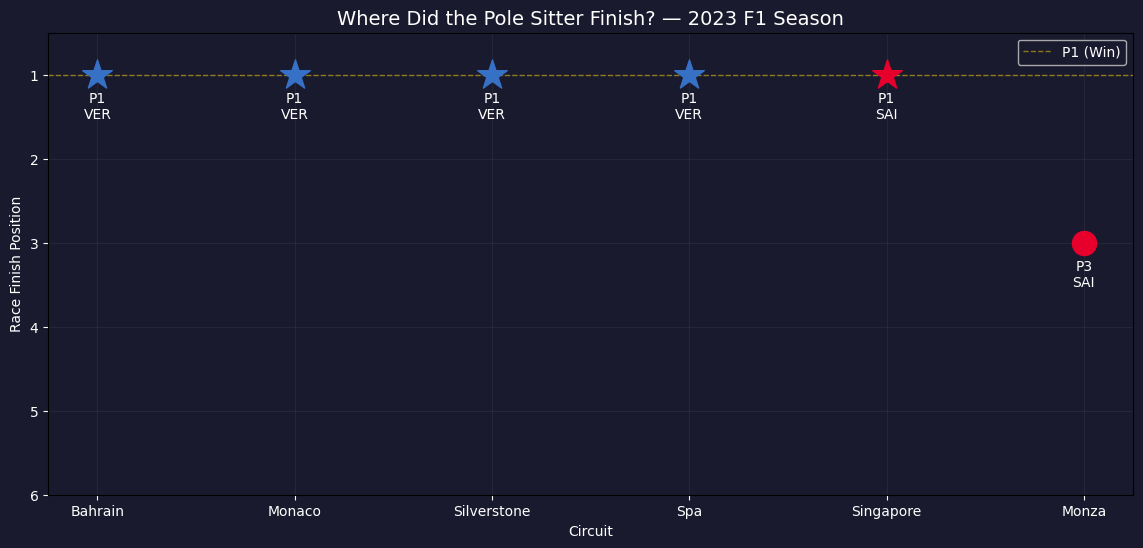

       Race Driver  RacePosition   Won
    Bahrain    VER           1.0  True
     Monaco    VER           1.0  True
Silverstone    VER           1.0  True
        Spa    VER           1.0  True
  Singapore    SAI           1.0  True
      Monza    SAI           3.0 False


In [9]:
pole_results = combined[combined['QualiPosition'] == 1][['Race', 'Driver', 'RacePosition']].copy()
pole_results['Won'] = pole_results['RacePosition'] == 1

fig, ax = setup_dark_plot(figsize=(14, 6))

team_colors = get_team_colors()

# Map driver to team for this subset
driver_team_map = combined[['Driver', 'Team']].drop_duplicates()
driver_team_map = dict(zip(driver_team_map['Driver'], driver_team_map['Team']))

for i, (_, row) in enumerate(pole_results.iterrows()):
    team = driver_team_map.get(row['Driver'], '')
    color = team_colors.get(team, '#FFFFFF')
    size = 500 if row['Won'] else 300
    ax.scatter(row['Race'], row['RacePosition'],
               color=color, s=size, zorder=5,
               marker='*' if row['Won'] else 'o')
    ax.text(i, row['RacePosition'] + 0.2,
            f"P{int(row['RacePosition'])}\n{row['Driver']}",
            ha='center', va='top', color='white', fontsize=10)

# Reference line at P1
ax.axhline(y=1, color='#FFD700', linewidth=1,
           linestyle='--', alpha=0.5, label='P1 (Win)')

ax.invert_yaxis()
ax.set_ylim(6, 0.5)
style_dark_labels(ax,
    title='Where Did the Pole Sitter Finish? — 2023 F1 Season',
    xlabel='Circuit',
    ylabel='Race Finish Position')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
save_figure('pole_to_win.png')
plt.show()
print(pole_results.to_string(index=False))

## 2. Driver Position Delta — Qualifying to Race
Which drivers consistently gain or lose positions from qualifying to race?
Positive = gained positions, Negative = lost positions.

Saved: driver_position_delta.png


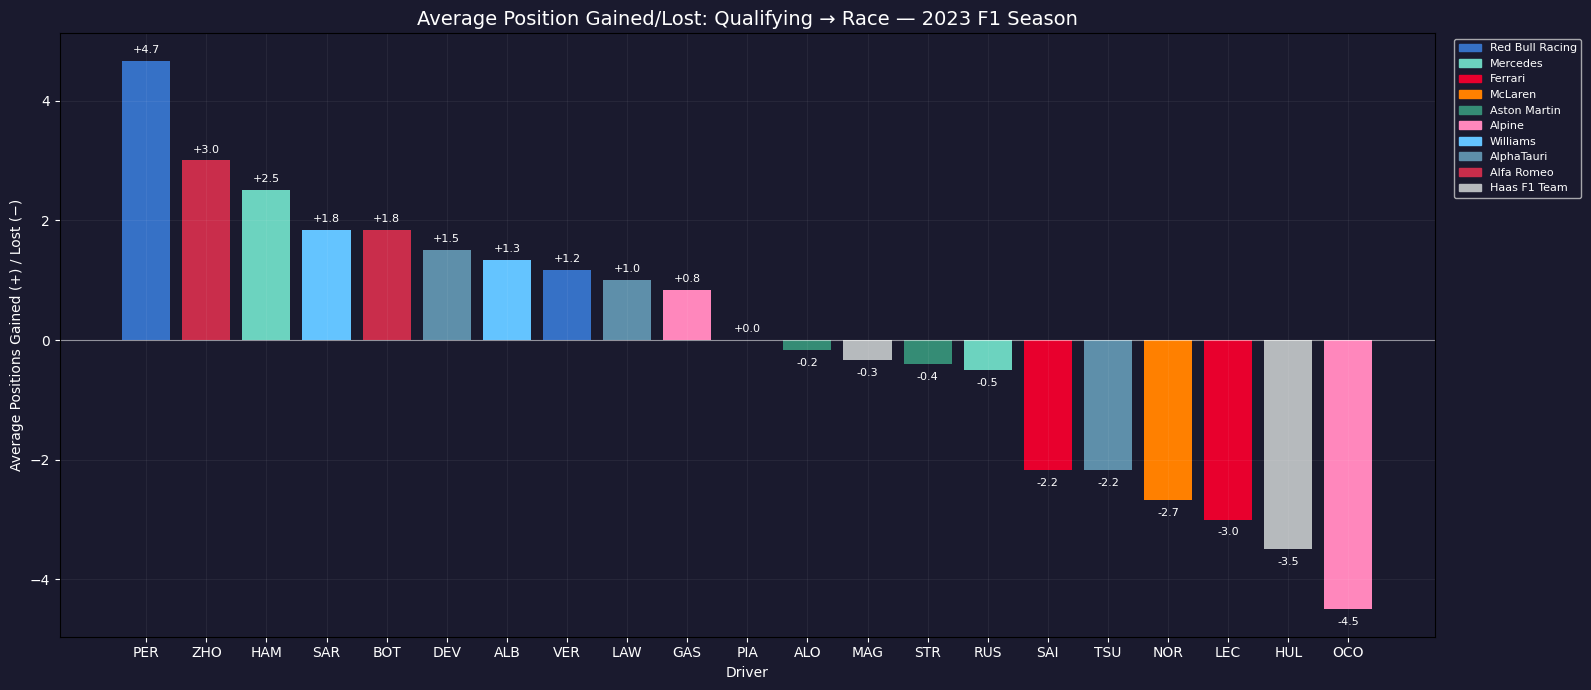

In [10]:
team_colors = get_team_colors()

# Average delta per driver across all races
driver_delta = combined.groupby(['Driver', 'Team'])['PositionDelta'].mean().reset_index()
driver_delta = driver_delta.sort_values('PositionDelta', ascending=False)

colors = [team_colors.get(team, '#FFFFFF') for team in driver_delta['Team']]

fig, ax = setup_dark_plot(figsize=(16, 7))
bars = ax.bar(driver_delta['Driver'], driver_delta['PositionDelta'],
              color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, driver_delta['PositionDelta']):
    ypos = bar.get_height() + 0.1 if val >= 0 else bar.get_height() - 0.3
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.1f}', ha='center', va='bottom',
            color='white', fontsize=8)

ax.axhline(y=0, color='white', linewidth=0.8, alpha=0.5)
style_dark_labels(ax,
    title='Average Position Gained/Lost: Qualifying → Race — 2023 F1 Season',
    xlabel='Driver',
    ylabel='Average Positions Gained (+) / Lost (−)')

# Add team color legend
legend_patches = [
    mpatches.Patch(color=color, label=team)
    for team, color in team_colors.items()
    if team in driver_delta['Team'].values
]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
save_figure('driver_position_delta.png')
plt.show()

## 3. Team Qualifying vs Race Performance
Which teams consistently outperform or underperform their qualifying position in races?

Saved: team_position_delta.png


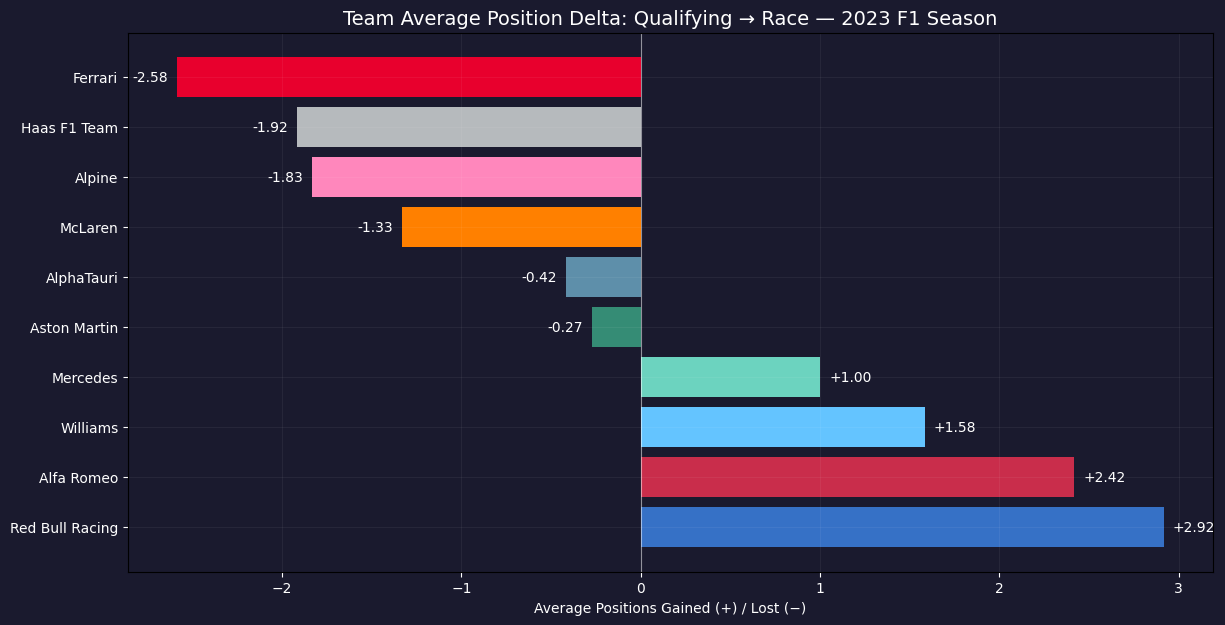

In [11]:
team_delta = combined.groupby('Team')['PositionDelta'].mean().sort_values(ascending=False)
colors = [team_colors.get(team, '#FFFFFF') for team in team_delta.index]

fig, ax = setup_dark_plot(figsize=(14, 7))
bars = ax.barh(team_delta.index, team_delta.values,
               color=colors, edgecolor='none')

for bar, val in zip(bars, team_delta.values):
    xpos = val + 0.05 if val >= 0 else val - 0.05
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha=ha,
            color='white', fontsize=10)

ax.axvline(x=0, color='white', linewidth=0.8, alpha=0.5)
style_dark_labels(ax,
    title='Team Average Position Delta: Qualifying → Race — 2023 F1 Season',
    xlabel='Average Positions Gained (+) / Lost (−)',
    ylabel='')
save_figure('team_position_delta.png')
plt.show()

## 4. Circuit-Level Qualifying vs Race Correlation
At which circuits does qualifying position most strongly predict race position?
A high correlation means qualifying is decisive. A low correlation means the race reshuffles the order.

Saved: quali_race_correlation.png


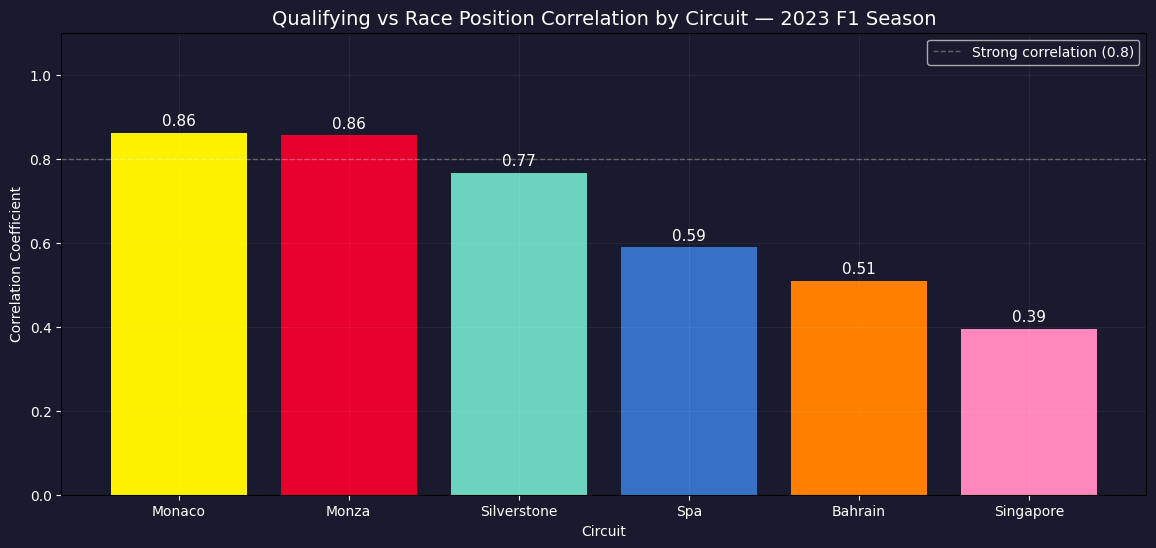


Correlations:
Race
Monaco         0.862
Monza          0.856
Silverstone    0.766
Spa            0.589
Bahrain        0.510
Singapore      0.395


In [ ]:
circuit_colors = get_circuit_colors()

correlations = combined.groupby('Race')[['QualiPosition', 'RacePosition']].corr().unstack()['RacePosition']['QualiPosition']
correlations = correlations.sort_values(ascending=False)
colors = [circuit_colors.get(r, '#FFFFFF') for r in correlations.index]

fig, ax = setup_dark_plot(figsize=(14, 6))
bars = ax.bar(correlations.index, correlations.values,
              color=colors, edgecolor='none')

for bar, val in zip(bars, correlations.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom',
            color='white', fontsize=11)

ax.set_ylim(0, 1.1)
ax.axhline(y=0.8, color='white', linewidth=1,
           linestyle='--', alpha=0.3, label='Strong correlation (0.8)')
style_dark_labels(ax,
    title='Qualifying vs Race Position Correlation by Circuit — 2023 F1 Season',
    xlabel='Circuit',
    ylabel='Correlation Coefficient')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
save_figure('quali_race_correlation.png')
plt.show()
print("\nCorrelations:")
print(correlations.round(3).to_string())

## 5. Head to Head — Qualifying vs Race Position per Driver per Circuit
A scatter plot showing every driver's qualifying position vs their race finish.
Points above the diagonal = gained positions in the race.
Points below = lost positions.

Saved: quali_vs_race_scatter.png


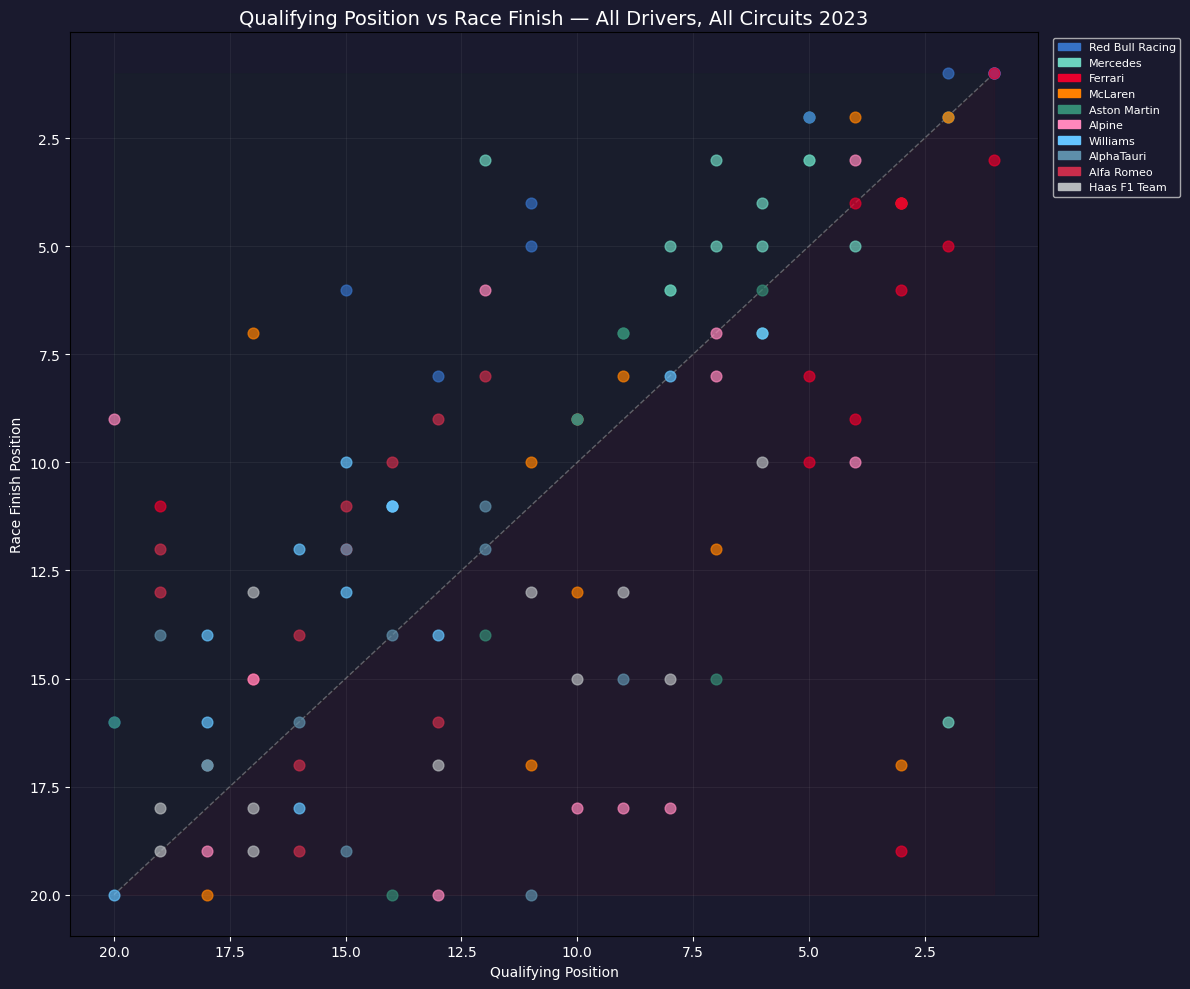

In [13]:
fig, ax = setup_dark_plot(figsize=(12, 10))

for _, row in combined.iterrows():
    color = team_colors.get(row['Team'], '#FFFFFF')
    ax.scatter(row['QualiPosition'], row['RacePosition'],
               color=color, alpha=0.7, s=60, zorder=3)

# Diagonal line — points on this line = no change
max_pos = 20
ax.plot([1, max_pos], [1, max_pos], color='white',
        linewidth=1, linestyle='--', alpha=0.3, label='No change line')

# Shade areas
ax.fill_between([1, max_pos], [1, max_pos], [1, 1],
                alpha=0.03, color='green', label='Gained positions')
ax.fill_between([1, max_pos], [max_pos, max_pos], [1, max_pos],
                alpha=0.03, color='red', label='Lost positions')

style_dark_labels(ax,
    title='Qualifying Position vs Race Finish — All Drivers, All Circuits 2023',
    xlabel='Qualifying Position',
    ylabel='Race Finish Position')
ax.invert_xaxis()
ax.invert_yaxis()

# Team color legend
legend_patches = [
    mpatches.Patch(color=color, label=team)
    for team, color in team_colors.items()
    if team in combined['Team'].values
]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()
save_figure('quali_vs_race_scatter.png')
plt.show()

## Summary

Key findings from qualifying vs race comparison:
- Pole position does not guarantee a win — circuit characteristics matter more than starting position
- Some drivers consistently gain positions in races suggesting strong race craft over single lap pace
- Monaco shows the highest correlation between qualifying and race position — grid position is destiny there
- Teams that struggle in qualifying can recover in races through strategy